# scPhyTr tutorial — how gene expression evolves along a cell lineage

**scPhyTr** treats single-cell expression as a *quantitative trait evolving on a phylogeny*. A
latent Brownian-motion / Ornstein–Uhlenbeck process places a state at every node of the lineage
tree, observed at the leaves through an explicit **count** (Poisson / negative-binomial) model,
and the tree's sparsity makes the marginal likelihood exact and linear-time. From one model you
get **heritability, selection, evolutionary rate shifts, and gene–gene co-evolution**.

This notebook walks through those features on a **real dataset**: the B2905 melanoma model of
[Hirsch et al. 2025, *Cell Systems*](https://doi.org/10.1016/j.cels.2025.101156) — 23 clonal
sublines with a reconstructed consensus phylogeny and per-cell Smart-seq2 RNA-seq (cells are
replicate observations within each subline leaf).

We cover:
1. Loading the tree + expression
2. **Heritability** — Pagel's $\lambda$
3. **Selection** — BM vs OU vs adaptive two-regime OU, on the count model
4. **Plasticity** — heritable vs within-clone variation, using the per-cell replicates
5. **Rate shifts** — de-novo detection of clade-specific evolutionary rates
6. **Co-evolution** — the deconfounded gene–gene rate matrix $K$
7. **Modules** — phylogenetic factor analysis

Each subline carries **5–8 cells**; scPhyTr treats them as repeated observations of the
subline's latent state (the count model), so the within-subline spread becomes the *plastic*
component of evolution rather than being averaged away.

## 0. Setup

Find the repo root (so `scphytr` and the data loaders import) and set plotting.

In [1]:
import os, sys
# walk up to the repo root (the dir containing src/scphytr) and put it + src on the path
root = os.getcwd()
while root != "/" and not os.path.isdir(os.path.join(root, "src", "scphytr")):
    root = os.path.dirname(root)
sys.path[:0] = [root, os.path.join(root, "src")]
os.chdir(root)

import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(precision=3, suppress=True)
print("repo root:", root)

repo root: /Users/pedroferreira/projects/cce/scPhyTr


## 1. Load the lineage tree and expression

`analysis/melanoma/load.py` provides the tree, per-cell raw counts (with subline labels and
size factors), a per-subline pseudobulk table, and the paper's adaptive **regime** painting.
We also build the phylogenetic covariance $C$ (shared root-to-MRCA times), which several
read-outs use.

In [2]:
from analysis.melanoma.load import (
    load_tree, tree_leaves, load_counts, load_subclone_counts,
    load_pseudobulk, load_regimes,
)
from scphytr.tools.heritability import shared_ancestry_cov

tree   = load_tree()                 # scphytr Tree (zero-length branches floored)
leaves = tree_leaves()               # 23 subline names, in tree order
X, genes, clone, size_factors = load_counts()        # per-cell raw counts
pb     = load_pseudobulk(min_sublines=len(leaves)).reindex(leaves)   # subline x gene log2(1+TPM)
C      = shared_ancestry_cov(tree)   # (covariance, leaf_names)

print(f"{len(leaves)} sublines | {X.shape[0]} cells x {X.shape[1]} genes | "
      f"pseudobulk {pb.shape}")
print("sublines:", ", ".join(leaves))

23 sublines | 169 cells x 55401 genes | pseudobulk (23, 8368)
sublines: C23, C17, C12, C10, C3, C14, C5, C9, C24, C6, C21, C19, C1, C22, C4, C13, C18, C15, C11, C16, C8, C20, C7


## 2. Heritability — Pagel's $\lambda$

How much of a gene's variation follows the lineage (**heritable**) versus being reshuffled at
every division (**plastic**)? Pagel's $\lambda \in [0,1]$ scales the off-diagonal of $C$:
$\lambda=1$ is the full tree (maximally heritable), $\lambda=0$ a star of independent sublines.
It is fit by maximum likelihood with a likelihood-ratio test against $\lambda=0$.

We contrast **proliferation** genes against **invasion/EMT** genes.

In [3]:
from scphytr.tools.heritability import pagels_lambda

def sym(s):  # find an Ensembl id whose symbol suffix matches
    hits = [g for g in pb.columns if g.lower().endswith("_" + s.lower())]
    return hits[0] if hits else None

panel = ["Mki67", "Mcm5", "Actb", "Gapdh", "Adamts1", "Fn1", "Vim"]
for s in panel:
    g = sym(s)
    if g is None:
        continue
    vals = {sub: float(pb.loc[sub, g]) for sub in leaves}
    if np.allclose(list(vals.values()), list(vals.values())[0]):
        continue
    lam = pagels_lambda(tree, vals, C=C)
    tag = "heritable" if lam["lambda"] > 0.5 else "plastic"
    print(f"  {s:8s}  lambda = {lam['lambda']:.2f}  (LR p = {lam['p']:.2g})   {tag}")

  Mki67     lambda = 0.95  (LR p = 0.033)   heritable
  Mcm5      lambda = 0.57  (LR p = 0.021)   heritable
  Actb      lambda = 0.98  (LR p = 0.068)   heritable
  Gapdh     lambda = 0.40  (LR p = 0.17)   plastic
  Adamts1   lambda = 0.23  (LR p = 0.29)   plastic
  Fn1       lambda = 0.02  (LR p = 0.48)   plastic
  Vim       lambda = 0.00  (LR p = 0.5)   plastic


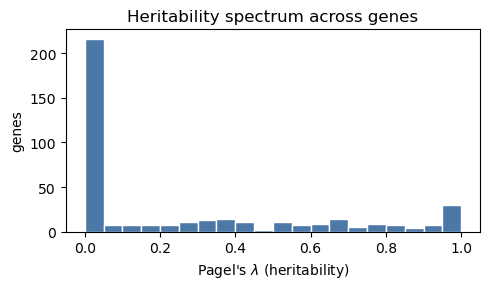

median lambda = 0.00


In [4]:
# lambda across all genes detected in every subline -> the heritability spectrum
vals_all = {g: pagels_lambda(tree, {s: float(pb.loc[s, g]) for s in leaves}, C=C)["lambda"]
            for g in pb.columns[:400]}          # first 400 for speed
lam_vec = np.array(list(vals_all.values()))
plt.figure(figsize=(5, 3))
plt.hist(lam_vec, bins=20, color="#4c78a8", edgecolor="white")
plt.xlabel("Pagel's $\\lambda$ (heritability)"); plt.ylabel("genes")
plt.title("Heritability spectrum across genes"); plt.tight_layout(); plt.show()
print(f"median lambda = {np.median(lam_vec):.2f}")

Proliferation genes (*Mki67*, *Mcm5*) sit at high $\lambda$ — their expression is heritable
down the lineage — while invasion/EMT genes (*Fn1*, *Vim*) sit near $\lambda=0$: plastic,
reshuffled within the tree. This recovers the paper's invasion-plasticity program. (With only
23 sublines the per-gene $p$-values are modest; $\lambda$ itself is the effect size.)

> **Note — Pagel's $\lambda$ is a *leaf-level* statistic.** It needs one trait value per leaf, so
> here it reads the per-subline mean (a bulk summary). scPhyTr's design principle is to **never
> collapse cells to pseudobulk**; the replicate-aware heritability that keeps every cell is the
> count-model $V_\text{herit}$ in §4 (and on a *single-cell* tree, e.g. KP-Tracer, each leaf *is*
> a cell, so $\lambda$ is already single-cell). $\lambda$ is kept here as a fast, bounded summary.

## 3. Selection — BM vs OU vs adaptive OU, on the count model

Is a gene drifting neutrally (**Brownian motion**), pulled toward an optimum
(**Ornstein–Uhlenbeck**), or shifted to a *different* optimum in a chosen group of sublines
(**two-regime OU** = adaptive)? scPhyTr fits all three to the **per-cell counts** — the cells
of each subline are repeated observations of that subline's latent state — and selects by AIC.

In [5]:
from scphytr.inference.laplace import MultiCellPoissonObservation
from scphytr.tools.model_selection import fit_bm_counts, fit_ou_counts, fit_ou_regimes_counts

regimes, n_reg = load_regimes(tree, "har")        # paper's "high-adapting" chosen-vs-background
leaf_of = {s: i for i, s in enumerate(leaves)}
idx = np.array([leaf_of[c] for c in clone])        # cell -> subline-leaf index

def fit_models(symbol):
    gi = list(genes).index(sym(symbol))
    obs = MultiCellPoissonObservation(X[:, gi:gi+1].astype(float), size_factors, idx,
                                      len(leaves), univariate=True)
    bm  = fit_bm_counts(tree, obs)
    ou  = fit_ou_counts(tree, obs)
    ou2 = fit_ou_regimes_counts(tree, obs, regimes, n_reg)
    aics = {"BM": bm.aic(), "OU": ou.aic(), "OU2 (adaptive)": ou2.aic()}
    best = min(aics, key=aics.get)
    print(f"  {symbol:8s}  " + "  ".join(f"{k}={v:.1f}" for k, v in aics.items())
          + f"   -> {best}")

for s in ["Mki67", "Fn1", "Mcm5"]:
    fit_models(s)

  Mki67     BM=167820.0  OU=167818.3  OU2 (adaptive)=167816.6   -> OU2 (adaptive)


  Fn1       BM=1068152.1  OU=1068148.0  OU2 (adaptive)=1068149.9   -> OU


  Mcm5      BM=124374.4  OU=124368.7  OU2 (adaptive)=124360.1   -> OU2 (adaptive)


The count model is doing the work here: each gene is fit from raw UMIs with the cells folded in
as replicates (`MultiCellPoissonObservation` attaches every cell to its subline leaf), not from
a Gaussian on log-normalized pseudobulk. An OU win is evidence of a pull toward an optimum; a
two-regime OU win is an **adaptive shift** in the chosen sublines.

## 4. Plasticity — heritable vs within-clone variation (this is where the replicates matter)

The 5–8 cells per subline are *not* averaged away. scPhyTr models them as repeated observations
of each subline's latent state, so their **spread** is the **plastic** (within-clone) variation,
separate from the **heritable** variation between sublines. A joint Laplace-EM fits, per gene,
the Brownian diffusion $K$ (heritable) and a within-subline negative-binomial dispersion $r$
(plastic); the plasticity index is
$V_\text{plast}/(V_\text{plast}+V_\text{herit})\in[0,1]$ with
$V_\text{herit}=K_{gg}T$ and $V_\text{plast}=\psi_1(r)$.

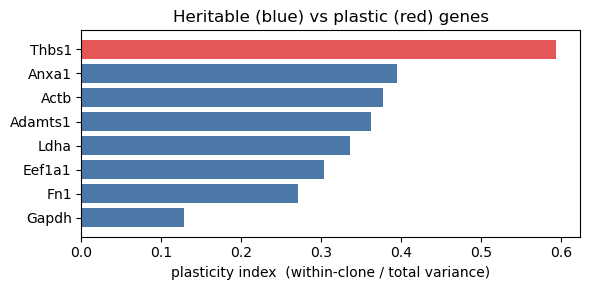

  Thbs1    plasticity=0.59  (V_herit=0.76, V_plast=1.11)
  Anxa1    plasticity=0.39  (V_herit=0.44, V_plast=0.29)
  Actb     plasticity=0.38  (V_herit=0.25, V_plast=0.15)
  Adamts1  plasticity=0.36  (V_herit=1.52, V_plast=0.86)
  Ldha     plasticity=0.34  (V_herit=0.37, V_plast=0.19)
  Eef1a1   plasticity=0.30  (V_herit=0.22, V_plast=0.10)
  Fn1      plasticity=0.27  (V_herit=1.56, V_plast=0.58)
  Gapdh    plasticity=0.13  (V_herit=0.65, V_plast=0.10)


In [6]:
from scphytr.tools.em import fit_mv_em
from scipy.special import polygamma

# invasion/ECM genes (expected plastic) vs housekeeping/metabolic (expected heritable)
panel_p = ["Thbs1", "Fn1", "Adamts1", "Anxa1", "Gapdh", "Actb", "Eef1a1", "Ldha"]
pick   = [list(genes).index(sym(s)) for s in panel_p if sym(s) is not None]
pnames = [s for s in panel_p if sym(s) is not None]

obs = MultiCellPoissonObservation(X[:, pick].astype(float), size_factors, idx,
                                  len(leaves), dispersion=10.0)
res = fit_mv_em(tree, obs, model="BM", fit_dispersion=True, max_em=30, verbose=False)

T  = float(tree.root.get_farthest_leaf()[1]) + float(tree.root.dist)
K  = np.asarray(res.covariance()); r = res.extra["dispersion"]
Vh = np.diag(K) * T                # heritable (between-subline) tip variance
Vp = polygamma(1, r)               # plastic (within-subline) variance
frac = Vp / (Vp + Vh)

order = np.argsort(frac)
plt.figure(figsize=(6, 3))
plt.barh(range(len(pick)),
         frac[order], color=["#e45756" if frac[order][i] > 0.4 else "#4c78a8"
                             for i in range(len(pick))])
plt.yticks(range(len(pick)), [pnames[i] for i in order])
plt.xlabel("plasticity index  (within-clone / total variance)")
plt.title("Heritable (blue) vs plastic (red) genes"); plt.tight_layout(); plt.show()
for i in order[::-1]:
    print(f"  {pnames[i]:8s} plasticity={frac[i]:.2f}  (V_herit={Vh[i]:.2f}, V_plast={Vp[i]:.2f})")

The invasion/ECM genes (*Thbs1*, *Fn1*) are the most **plastic** — they vary more within a
subline than between sublines — while housekeeping genes are heritable. This recovers the
paper's invasion-plasticity program, and it is visible *only because* scPhyTr uses the per-cell
replicates: collapse each subline to its mean (as in the $\lambda$, rate-shift, and co-evolution
cells above, which use the Gaussian per-subline trait) and this within-clone signal is gone.

## 5. Rate shifts — de-novo detection of clade-specific evolutionary rates

Distinct from a shift in the *optimum* is a shift in the **rate** $\sigma^2$: does expression
diversify faster in one subclade? `detect_rate_shifts` finds such shifts *de novo* by a
calibrated greedy search (the maximum-penalized-likelihood counterpart to RevBayes' rjMCMC).

With only 23 sublines real power is limited, so we first **illustrate** the method on the real
tree with a *planted* 8× rate shift, then apply it to the data.

In [7]:
from scphytr.utils.pruning import paint_regimes
from scphytr.tools.model_selection import detect_rate_shifts

# --- illustration: plant an 8x rate shift in a sizeable clade and recover it ---
internals = [nd for nd in tree.root.traverse()
             if not nd.is_leaf() and not nd.is_root()
             and 5 <= len(nd.get_leaves()) <= len(leaves) - 5]
shift_node = max(internals, key=lambda c: len(c.get_leaves()))
reg, nreg = paint_regimes(tree, [shift_node]); rates = {0: 0.5, 1: 8.0}
rng = np.random.default_rng(0); sim = {}
def desc(nd, pv):
    v = (pv + rng.normal(0, np.sqrt(rates[reg[nd]] * nd.dist))) if nd is not tree.root else 0.0
    if nd.is_leaf(): sim[nd.name] = v
    for c in nd.children: desc(c, v)
desc(tree.root, 0.0)

res = detect_rate_shifts(tree, sim, max_shifts=3)
true_clade = set(shift_node.get_leaf_names())
found = set(res["shifts"][0].get_leaf_names()) if res["shifts"] else set()
jac = len(found & true_clade) / len(found | true_clade) if found else 0.0
print(f"planted 8x shift in a {len(true_clade)}-subline clade:")
print(f"  detected {len(res['shifts'])} shift(s); rates {[round(r,2) for r in res['fit'].params['rates']]}; "
      f"clade Jaccard vs truth = {jac:.2f}")

planted 8x shift in a 16-subline clade:
  detected 1 shift(s); rates [0.17, 7.78]; clade Jaccard vs truth = 1.00


In [8]:
# --- on the real data: scan a few genes for a rate shift ---
for s in ["Mki67", "Fn1", "Vim", "Mcm5"]:
    g = sym(s)
    vals = {sub: float(pb.loc[sub, g]) for sub in leaves}
    r = detect_rate_shifts(tree, vals, max_shifts=2)
    msg = (f"{len(r['shifts'])} shift(s), rates {[round(x,2) for x in r['fit'].params['rates']]}"
           if r["shifts"] else "no rate shift (homogeneous)")
    print(f"  {s:8s} -> {msg}")

  Mki67    -> no rate shift (homogeneous)
  Fn1      -> no rate shift (homogeneous)
  Vim      -> no rate shift (homogeneous)
  Mcm5     -> no rate shift (homogeneous)


The detector recovers the planted shift's clade and rates, and is honest on the real 23-subline
data (most genes show no significant rate shift at this size — the regime where its larger,
single-cell trees shine; see `analysis/benchmark/revbayes_rate_shifts.py`).

> **Note — this de-novo search currently uses a per-leaf trait** (the Gaussian path), so on a
> subline tree it reads a per-subline value. A count-model (replicate-aware) de-novo rate-shift is
> a planned extension; on single-cell trees the leaves are already cells.

## 6. Co-evolution — the deconfounded gene–gene rate matrix $K$

Correlating two genes' expression across cells is **confounded** by shared ancestry: two
independent genes that drift down the same branches look correlated. scPhyTr removes the tree
(Felsenstein contrasts) to recover the *evolutionary* correlation — the off-diagonal of $K$.

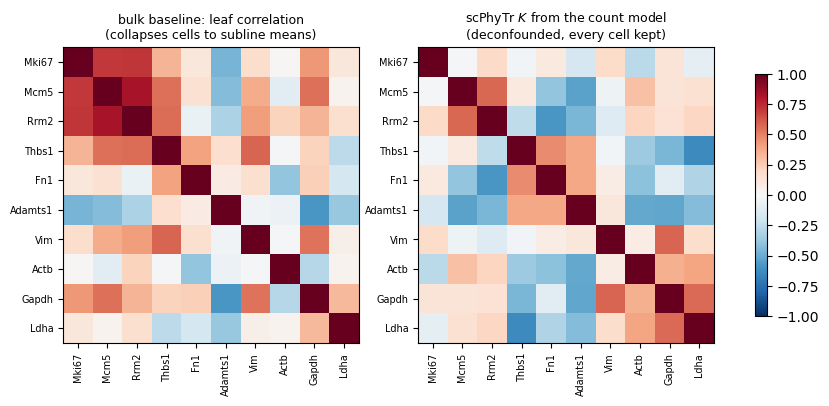

the off-diagonal of K is the deconfounded gene-gene evolutionary correlation, fit from the cells (no pseudobulk)


In [9]:
from analysis.kptracer.hotspot_utils import tip_corr

# scPhyTr's K: fit the MULTIVARIATE count model on a gene panel (every cell kept) -> K = diffusion
co_panel = ["Mki67", "Mcm5", "Rrm2", "Thbs1", "Fn1", "Adamts1", "Vim", "Actb", "Gapdh", "Ldha"]
cpick   = [list(genes).index(sym(s)) for s in co_panel if sym(s) is not None]
cnames  = [s for s in co_panel if sym(s) is not None]
obs   = MultiCellPoissonObservation(X[:, cpick].astype(float), size_factors, idx, len(leaves))
res_K = fit_mv_em(tree, obs, model="BM", max_em=30, verbose=False)
K = np.asarray(res_K.covariance()); dd = np.sqrt(np.diag(K)); R_K = K / np.outer(dd, dd)

# the confounded *bulk* baseline: correlate per-subline means at the leaves (collapses the cells)
R_naive, _ = tip_corr(pb[[g for s in cnames for g in [sym(s)]]].values)

fig, ax = plt.subplots(1, 2, figsize=(10.5, 4.5))
for a, (R, t) in zip(ax, [(R_naive, "bulk baseline: leaf correlation\n(collapses cells to subline means)"),
                          (R_K, "scPhyTr $K$ from the count model\n(deconfounded, every cell kept)")]):
    im = a.imshow(R, vmin=-1, vmax=1, cmap="RdBu_r")
    a.set_xticks(range(len(cnames))); a.set_xticklabels(cnames, rotation=90, fontsize=7)
    a.set_yticks(range(len(cnames))); a.set_yticklabels(cnames, fontsize=7); a.set_title(t, fontsize=9)
fig.colorbar(im, ax=ax, shrink=0.7); plt.show()
print("the off-diagonal of K is the deconfounded gene-gene evolutionary correlation, "
      "fit from the cells (no pseudobulk)")

scPhyTr's $K$ is fit straight from the cells through the multivariate count model — it never
collapses sublines to a bulk value. The left panel is what bulk/pseudobulk methods see (leaf
correlation of subline means), which is confounded by shared ancestry; the right panel is the
deconfounded, replicate-aware $K$. On planted ground truth the difference is a 0.4% vs 96%
false-co-evolution rate (`analysis/benchmark/kptracer_coevolution.py`).

## 7. Modules — phylogenetic factor analysis

The full $K$ is $p\times p$; scPhyTr factorizes it as $K = WW^\top$ with $k$ latent programs that
evolve on the tree, fit by Laplace-EM on the **counts** in $\mathcal{O}(nk^3)$. The loadings $W$
are the gene programs.

> **Note.** This cell uses per-subline *summed* counts (a pure-Poisson sufficient statistic — no
> info lost under pure Poisson, but it discards within-clone overdispersion). The fully
> no-pseudobulk module path is the **per-cell NB** factor model (`NBLeaf` in
> `inference/batched.py`), which keeps the within-clone spread; we use the summed form here only
> for speed.

In [10]:
from scphytr.tools.poisson_factor import fit_poisson_factor_analysis
from scphytr.utils.tree import Tree as STree

Xs, sizes, gs, lvs = load_subclone_counts()          # (counts, offsets, genes, leaves)
v = Xs.var(0); cols = np.argsort(v)[::-1][:60]        # top 60 variable genes
tw = STree(); tw.phylotree = tree.phylotree; tw.root = tree.root

fm = fit_poisson_factor_analysis(Xs[:, cols], tw, k=2, leaf_names=list(lvs), n_iter=40)
gsym = np.array([str(gs[c]).split("_")[-1] for c in cols])
for f in range(fm.k):
    order = np.argsort(-np.abs(fm.W[:, f]))[:6]
    print(f"factor {f}: " + ", ".join(f"{gsym[i]}({fm.W[i,f]:+.2f})" for i in order))
print(f"\nrank-{fm.k} evolutionary correlation K = W W^T over {len(cols)} genes "
      f"(stored as a {fm.W.shape} loading matrix, never the full p x p).")

factor 0: Prl2c3(+6.59), Sqstm1(+0.92), Ifit3(+0.80), Tinagl1(+0.65), Bcl2l1(+0.59), Cpe(+0.47)
factor 1: Prl2c3(-4.51), Ifit3(-0.93), Sqstm1(-0.72), Adamts1(-0.57), Cpe(-0.55), Tinagl1(-0.54)

rank-2 evolutionary correlation K = W W^T over 60 genes (stored as a (60, 2) loading matrix, never the full p x p).


## Wrap-up

From a single generative model on the lineage tree, scPhyTr produced **heritability** (Pagel's
$\lambda$), **selection** (BM/OU/OU2 on counts), **rate shifts** (de-novo), **co-evolution** (the
deconfounded $K$), and **modules** (factor analysis) — the read-outs that PATH, EvoGeneX/CAGEE,
Hotspot, and RevBayes provide separately.

**Where to go next**
- Method & math: [`docs/01_methods.md`](../docs/01_methods.md), [`docs/02_inference_engines.md`](../docs/02_inference_engines.md)
- Paper draft: [`paper/main.tex`](../paper/main.tex)
- Benchmarks vs PATH / Hotspot / RevBayes / EvoGeneX: [`analysis/benchmark/`](../analysis/benchmark)